In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning

from src.fine_tuning.regression_tuning import (
    tune_regression_datasets,
    compare_tuned_vs_baseline_regression,
)
from src.fine_tuning.classification_tuning import (
    tune_classification_datasets,
    compare_tuned_vs_baseline_classification,
)
from src.utils.config import PROCESSED_DATA_DIR, TABLES_DIR, FIGURES_DIR

TABLES_DIR.mkdir(parents = True, exist_ok = True)
FIGURES_DIR.mkdir(parents = True, exist_ok = True)

pd.set_option("display.max_columns", 200)

warnings.filterwarnings("ignore", category = ConvergenceWarning)

In [7]:
# import baseline results

baseline_reg = pd.read_csv(TABLES_DIR / "regression_best_rmse.csv")
baseline_bin = pd.read_csv(TABLES_DIR / "binary_best_f1.csv")
baseline_q = pd.read_csv(TABLES_DIR / "quantile_best_f1.csv")

print("Baseline regression summary:")
display(baseline_reg)

print("Baseline binary classification summary:")
display(baseline_bin)

print("Baseline quantile classification summary:")
display(baseline_q)

Baseline regression summary:


,position,model,rmse,mae,r2
0,DB,SVR,8.621390,6.681314,-0.002204
1,DL,SVR,8.547665,7.038273,-0.102731
2,LB,SVR,10.232549,7.451565,-0.017047
3,OL,SVR,9.601728,8.241589,-0.077662
4,QB,RF,17.047866,13.710137,0.294901
5,RB,SVR,11.873728,9.016037,-0.041186
6,TE,SVR,7.034330,5.265255,0.030003
7,WR,Ridge,12.871412,10.254101,0.076585


Baseline binary classification summary:


,position,model,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,recall_star
0,DB,SVC,0.629268,0.552299,0.643757,0.552276,0.561212,0.423077
1,DL,NaiveBayes,0.780220,0.620833,0.804533,0.607334,0.669675,0.521739
2,LB,GB,0.723077,0.579288,0.726861,0.577381,0.581731,0.346154
3,OL,ExtraTrees,0.715328,0.588779,0.750296,0.587271,0.646795,0.550000
4,QB,GB,0.750000,0.715100,0.754986,0.708791,0.726190,0.666667
5,RB,ExtraTrees,0.762712,0.594502,0.745006,0.616773,0.586237,0.280000
6,TE,SVC,0.759036,0.645299,0.768716,0.636508,0.660448,0.500000
7,WR,Logistic,0.657754,0.596221,0.672926,0.594353,0.612935,0.520833


Baseline quantile classification summary:


,position,model,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,recall_star
0,DB,CatBoost,0.400000,0.396061,0.395948,0.393122,0.406893,0.500000
1,DL,CatBoost,0.395604,0.388986,0.409906,0.433977,0.475150,0.695652
2,LB,XGBoost,0.346154,0.344294,0.354458,0.371426,0.362324,0.464286
3,OL,ExtraTrees,0.408759,0.404421,0.423390,0.473145,0.471269,0.714286
4,QB,ExtraTrees,0.466667,0.413781,0.425776,0.477602,0.447411,0.578947
5,RB,RF,0.398305,0.397187,0.400016,0.403175,0.414052,0.481481
6,TE,Logistic,0.385542,0.373840,0.391242,0.428896,0.402299,0.555556
7,WR,Logistic,0.475936,0.469862,0.483565,0.493893,0.471396,0.395833


In [8]:
positions = ["qb", "rb", "wr", "te", "dl", "lb", "db", "ol"]

reg_datasets = {}
q_datasets = {}
bin_datasets = {}

for pos in positions:
    reg_datasets[pos.upper()] = pd.read_csv(PROCESSED_DATA_DIR / f"{pos}_regression_data.csv")
    q_datasets[pos.upper()] = pd.read_csv(PROCESSED_DATA_DIR / f"{pos}_quantile_data.csv")
    bin_datasets[pos.upper()] = pd.read_csv(PROCESSED_DATA_DIR / f"{pos}_binary_data.csv")

print("Loaded regression datasets:")
for pos, df_pos in reg_datasets.items():
    print(pos, df_pos.shape)

print("\nLoaded quantile datasets:")
for pos, df_pos in q_datasets.items():
    print(pos, df_pos.shape)

print("\nLoaded binary datasets:")
for pos, df_pos in bin_datasets.items():
    print(pos, df_pos.shape)

Loaded regression datasets:
QB (211, 20)
RB (403, 19)
WR (647, 16)
TE (280, 16)
DL (802, 14)
LB (574, 15)
DB (897, 14)
OL (683, 11)

Loaded quantile datasets:
QB (211, 20)
RB (403, 19)
WR (647, 16)
TE (280, 16)
DL (802, 14)
LB (574, 15)
DB (897, 14)
OL (683, 11)

Loaded binary datasets:
QB (211, 20)
RB (403, 19)
WR (647, 16)
TE (280, 16)
DL (802, 14)
LB (574, 15)
DB (897, 14)
OL (683, 11)


In [24]:
# Choose models to tune based on baseline
reg_models_to_tune = ["SVR", "RF", "Ridge"]
bin_models_to_tune = ["SVC", "NaiveBayes", "GB", "ExtraTrees", "Logistic"]
q_models_to_tune = ["CatBoost", "XGBoost", "ExtraTrees", "RF", "Logistic"]

# Regression

In [25]:
# Fine tune regression models
tuned_reg_all = tune_regression_datasets(
    reg_datasets,
    model_names = reg_models_to_tune,
    cv = 5,
    scoring = "neg_root_mean_squared_error",
)

print("=== ALL TUNED REGRESSION RESULTS ===")
display(tuned_reg_all.sort_values(["position", "rmse"]))

=== ALL TUNED REGRESSION RESULTS ===


,position,model,best_params,cv_best_score,rmse,mae,r2
18,DB,SVR,"{'C': 100.0, 'epsilon': 0.5, 'kernel': 'linear'}",-14.818683,8.558056,7.033873,0.012467
20,DB,Ridge,{'alpha': 100.0},-14.679349,8.838004,7.435558,-0.053198
19,DB,RF,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",-14.820386,9.046174,7.612059,-0.103396
12,DL,SVR,"{'C': 100.0, 'epsilon': 0.5, 'kernel': 'linear'}",-19.902436,10.545664,8.629539,-0.678505
13,DL,RF,"{'max_depth': 12, 'min_samples_leaf': 4, 'min_...",-19.817129,13.912941,12.267319,-1.921545
14,DL,Ridge,{'alpha': 1.0},-19.427427,14.692754,12.661114,-2.258226
15,LB,SVR,"{'C': 100.0, 'epsilon': 0.1, 'kernel': 'linear'}",-19.684509,10.704925,8.837104,-0.113117
16,LB,RF,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",-18.857604,12.623023,10.893163,-0.547748
17,LB,Ridge,{'alpha': 1.0},-19.009411,13.304598,11.436624,-0.719400
21,OL,SVR,"{'C': 100.0, 'epsilon': 0.01, 'kernel': 'linear'}",-21.160126,12.764396,10.991257,-0.904515


In [26]:
# Best tuned regression model per position
best_tuned_reg = (
    tuned_reg_all.dropna(subset = ["rmse"])
    .sort_values("rmse", ascending=True)
    .groupby("position")
    .first()
    .reset_index()
)

print("=== BEST TUNED REGRESSION BY POSITION ===")
display(best_tuned_reg[["position", "model", "rmse", "mae", "r2", "cv_best_score", "best_params"]])

=== BEST TUNED REGRESSION BY POSITION ===


,position,model,rmse,mae,r2,cv_best_score,best_params
0,DB,SVR,8.558056,7.033873,0.012467,-14.818683,"{'C': 100.0, 'epsilon': 0.5, 'kernel': 'linear'}"
1,DL,SVR,10.545664,8.629539,-0.678505,-19.902436,"{'C': 100.0, 'epsilon': 0.5, 'kernel': 'linear'}"
2,LB,SVR,10.704925,8.837104,-0.113117,-19.684509,"{'C': 100.0, 'epsilon': 0.1, 'kernel': 'linear'}"
3,OL,SVR,12.764396,10.991257,-0.904515,-21.160126,"{'C': 100.0, 'epsilon': 0.01, 'kernel': 'linear'}"
4,QB,RF,18.777544,15.016533,0.144564,-35.892753,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s..."
5,RB,SVR,11.923575,9.691476,-0.049946,-19.288928,"{'C': 1.0, 'epsilon': 0.5, 'kernel': 'linear'}"
6,TE,SVR,7.225329,5.790290,-0.023387,-13.724151,"{'C': 10.0, 'epsilon': 0.01, 'kernel': 'linear'}"
7,WR,Ridge,12.864729,10.263158,0.077544,-18.088294,{'alpha': 100.0}


In [27]:
# Compare best tuned regression vs baseline regression
reg_compare = compare_tuned_vs_baseline_regression(
    baseline_df = baseline_reg,
    tuned_df = best_tuned_reg,
    metric = "rmse",
)

print("=== BASELINE VS BEST TUNED REGRESSION (RMSE) ===")
display(reg_compare.sort_values("position"))

=== BASELINE VS BEST TUNED REGRESSION (RMSE) ===


,position,baseline_model,baseline_rmse,tuned_model,tuned_rmse,improvement
0,DB,SVR,8.621390,SVR,8.558056,0.063334
1,DL,SVR,8.547665,SVR,10.545664,-1.997999
2,LB,SVR,10.232549,SVR,10.704925,-0.472376
3,OL,SVR,9.601728,SVR,12.764396,-3.162668
4,QB,RF,17.047866,RF,18.777544,-1.729678
5,RB,SVR,11.873728,SVR,11.923575,-0.049847
6,TE,SVR,7.034330,SVR,7.225329,-0.190999
7,WR,Ridge,12.871412,Ridge,12.864729,0.006683


In [28]:
# Save regression tuning outputs
tuned_reg_all.to_csv(TABLES_DIR / "tuned_regression_all_results.csv", index=False)
best_tuned_reg.to_csv(TABLES_DIR / "tuned_regression_best_by_position.csv", index=False)
reg_compare.to_csv(TABLES_DIR / "tuned_vs_baseline_regression.csv", index=False)

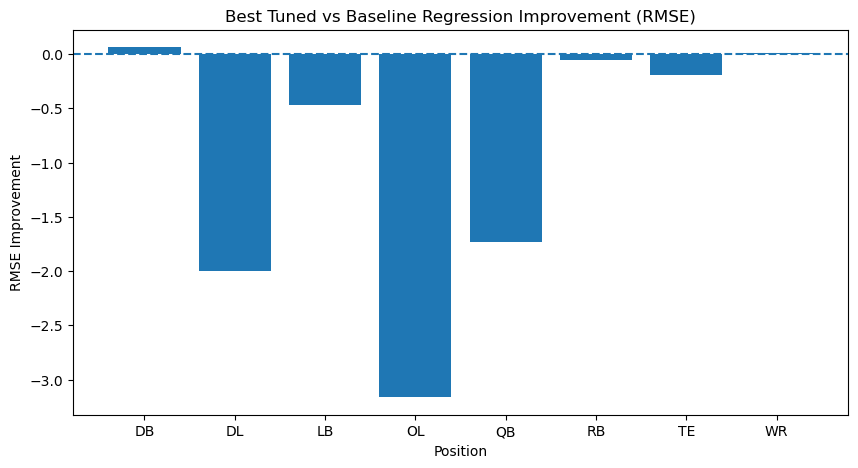

In [46]:
# regression RMSE improvement plot
plt.figure(figsize = (10, 5))
plt.bar(reg_compare["position"], reg_compare["improvement"])
plt.axhline(0, linestyle="--")
plt.title("Best Tuned vs Baseline Regression Improvement (RMSE)")
plt.xlabel("Position")
plt.ylabel("RMSE Improvement")
plt.savefig(FIGURES_DIR / "tuned_vs_baseline_regression_improvement.png")
plt.show()

# Binary

In [63]:
# Fine tune binary classification models
tuned_bin_all = tune_classification_datasets(
    bin_datasets,
    label_col = "star",
    positive_class = 1,
    model_names = bin_models_to_tune,
    cv = 5,
    scoring = "f1_macro",
)

print("=== ALL TUNED BINARY CLASSIFICATION RESULTS ===")
display(tuned_bin_all.sort_values(["position", "f1_macro"], ascending=[True, False]))

=== ALL TUNED BINARY CLASSIFICATION RESULTS ===


,position,model,label_col,positive_class,best_params,cv_best_score,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,recall_star
30,DB,SVC,star,1,"{'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}",0.569226,0.614634,0.588134,0.639606,0.611053,0.646619,0.711538
34,DB,Logistic,star,1,{'C': 0.1},0.586582,0.585366,0.563382,0.611651,0.596367,0.627011,0.711538
33,DB,ExtraTrees,star,1,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",0.561696,0.604878,0.545678,0.626478,0.551085,0.563914,0.480769
32,DB,GB,star,1,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.525393,0.692683,0.524152,0.663673,0.540601,0.527526,0.192308
31,DB,NaiveBayes,star,1,{'var_smoothing': 1e-09},0.307477,0.248780,0.199219,0.101067,0.125000,0.490385,0.980769
21,DL,NaiveBayes,star,1,{'var_smoothing': 1e-10},0.541088,0.780220,0.620833,0.804533,0.607334,0.669675,0.521739
23,DL,ExtraTrees,star,1,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.588773,0.692308,0.559246,0.740210,0.569519,0.637955,0.565217
22,DL,GB,star,1,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.566278,0.725275,0.557823,0.761157,0.558235,0.601039,0.434783
24,DL,Logistic,star,1,{'C': 10.0},0.614326,0.604396,0.526042,0.670043,0.580109,0.680613,0.782609
20,DL,SVC,star,1,"{'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}",0.548200,0.648352,0.512799,0.704832,0.536881,0.575608,0.478261


In [64]:
# Best tuned binary model per position
best_tuned_bin = (
    tuned_bin_all.dropna(subset=["f1_macro"])
    .sort_values("f1_macro", ascending=False)
    .groupby("position")
    .first()
    .reset_index()
)

print("=== BEST TUNED BINARY CLASSIFICATION BY POSITION ===")
display(
    best_tuned_bin[
        ["position", "model", "accuracy", "f1_macro", "recall_star", "cv_best_score", "best_params"]
    ]
)

=== BEST TUNED BINARY CLASSIFICATION BY POSITION ===


,position,model,accuracy,f1_macro,recall_star,cv_best_score,best_params
0,DB,SVC,0.614634,0.588134,0.711538,0.569226,"{'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}"
1,DL,NaiveBayes,0.780220,0.620833,0.521739,0.541088,{'var_smoothing': 1e-10}
2,LB,GB,0.723077,0.579288,0.346154,0.562606,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
3,OL,GB,0.766423,0.608571,0.450000,0.541594,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
4,QB,ExtraTrees,0.800000,0.753762,0.611111,0.528632,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
5,RB,GB,0.720339,0.598515,0.400000,0.547616,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
6,TE,SVC,0.759036,0.645299,0.500000,0.629084,"{'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}"
7,WR,ExtraTrees,0.705882,0.606436,0.395833,0.626550,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."


In [65]:
# Compare best tuned binary classification vs baseline
bin_compare = compare_tuned_vs_baseline_classification(
    baseline_df = baseline_bin,
    tuned_df = best_tuned_bin,
    metric = "f1_macro",
)

print("=== BASELINE VS BEST TUNED BINARY CLASSIFICATION (F1 MACRO) ===")
display(bin_compare.sort_values("position"))

=== BASELINE VS BEST TUNED BINARY CLASSIFICATION (F1 MACRO) ===


,position,baseline_model,baseline_f1_macro,tuned_model,tuned_f1_macro,improvement
0,DB,SVC,0.552299,SVC,0.588134,0.035835
1,DL,NaiveBayes,0.620833,NaiveBayes,0.620833,0.000000
2,LB,GB,0.579288,GB,0.579288,0.000000
3,OL,ExtraTrees,0.588779,GB,0.608571,0.019793
4,QB,GB,0.715100,ExtraTrees,0.753762,0.038662
5,RB,ExtraTrees,0.594502,GB,0.598515,0.004014
6,TE,SVC,0.645299,SVC,0.645299,0.000000
7,WR,Logistic,0.596221,ExtraTrees,0.606436,0.010215


In [66]:
# Save binary tuning outputs
tuned_bin_all.to_csv(TABLES_DIR / "tuned_binary_all_results.csv", index=False)
best_tuned_bin.to_csv(TABLES_DIR / "tuned_binary_best_by_position.csv", index=False)
bin_compare.to_csv(TABLES_DIR / "tuned_vs_baseline_binary.csv", index=False)

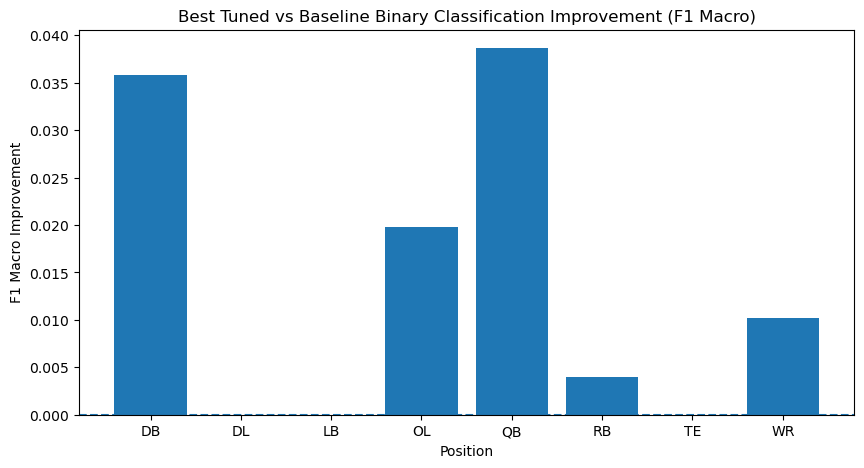

In [67]:
# binary classification F1 improvement plot
plt.figure(figsize = (10, 5))
plt.bar(bin_compare["position"], bin_compare["improvement"])
plt.axhline(0, linestyle="--")
plt.title("Best Tuned vs Baseline Binary Classification Improvement (F1 Macro)")
plt.xlabel("Position")
plt.ylabel("F1 Macro Improvement")
plt.savefig(FIGURES_DIR / "tuned_vs_baseline_binary_improvement.png")
plt.show()

# Quantile

In [68]:
# Fine tune quantile classification models
tuned_q_all = tune_classification_datasets(
    q_datasets,
    label_col = "av_class_q",
    positive_class = 2,
    model_names = q_models_to_tune,
    cv = 5,
    scoring = "f1_macro",
)

print("=== ALL TUNED QUANTILE CLASSIFICATION RESULTS ===")
display(tuned_q_all.sort_values(["position", "f1_macro"], ascending=[True, False]))

=== ALL TUNED QUANTILE CLASSIFICATION RESULTS ===


,position,model,label_col,positive_class,best_params,cv_best_score,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,recall_star
20,DB,Logistic,av_class_q,2,{'C': 0.1},0.414023,0.404878,0.399555,0.397897,0.411008,0.424264,0.615385
19,DB,RF,av_class_q,2,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.382031,0.351220,0.342378,0.351661,0.342375,0.345085,0.326923
18,DB,ExtraTrees,av_class_q,2,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.385773,0.341463,0.335895,0.344506,0.337996,0.337369,0.326923
12,DL,ExtraTrees,av_class_q,2,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.409424,0.439560,0.416198,0.461593,0.452861,0.497892,0.739130
13,DL,RF,av_class_q,2,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.400244,0.428571,0.415647,0.447488,0.450066,0.486415,0.652174
14,DL,Logistic,av_class_q,2,{'C': 1.0},0.399969,0.417582,0.380324,0.435457,0.418470,0.451230,0.652174
15,LB,ExtraTrees,av_class_q,2,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.409979,0.307692,0.305966,0.301427,0.336181,0.347112,0.571429
17,LB,Logistic,av_class_q,2,{'C': 0.1},0.418407,0.300000,0.294330,0.285319,0.315418,0.339837,0.535714
16,LB,RF,av_class_q,2,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.409387,0.269231,0.265895,0.255849,0.300829,0.316248,0.571429
21,OL,ExtraTrees,av_class_q,2,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",0.410830,0.401460,0.386715,0.405405,0.435736,0.432810,0.571429


In [69]:
# Best tuned quantile model per position
best_tuned_q = (
    tuned_q_all.dropna(subset=["f1_macro"])
    .sort_values("f1_macro", ascending=False)
    .groupby("position")
    .first()
    .reset_index()
)

print("=== BEST TUNED QUANTILE CLASSIFICATION BY POSITION ===")
display(
    best_tuned_q[
        ["position", "model", "accuracy", "f1_macro", "recall_star", "cv_best_score", "best_params"]
    ]
)

=== BEST TUNED QUANTILE CLASSIFICATION BY POSITION ===


,position,model,accuracy,f1_macro,recall_star,cv_best_score,best_params
0,DB,Logistic,0.404878,0.399555,0.615385,0.414023,{'C': 0.1}
1,DL,ExtraTrees,0.439560,0.416198,0.739130,0.409424,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
2,LB,ExtraTrees,0.307692,0.305966,0.571429,0.409979,"{'max_depth': None, 'min_samples_split': 2, 'n..."
3,OL,ExtraTrees,0.401460,0.386715,0.571429,0.410830,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
4,QB,Logistic,0.450000,0.394768,0.473684,0.366393,{'C': 1.0}
5,RB,ExtraTrees,0.389831,0.387604,0.518519,0.430361,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
6,TE,Logistic,0.373494,0.361516,0.666667,0.467891,{'C': 10.0}
7,WR,Logistic,0.465241,0.459942,0.395833,0.455262,{'C': 10.0}


In [70]:
# Compare best tuned quantile classification vs baseline
q_compare = compare_tuned_vs_baseline_classification(
    baseline_df=baseline_q,
    tuned_df=best_tuned_q,
    metric="f1_macro",
)

print("=== BASELINE VS BEST TUNED QUANTILE CLASSIFICATION (F1 MACRO) ===")
display(q_compare.sort_values("position"))

=== BASELINE VS BEST TUNED QUANTILE CLASSIFICATION (F1 MACRO) ===


,position,baseline_model,baseline_f1_macro,tuned_model,tuned_f1_macro,improvement
0,DB,CatBoost,0.396061,Logistic,0.399555,0.003494
1,DL,CatBoost,0.388986,ExtraTrees,0.416198,0.027213
2,LB,XGBoost,0.344294,ExtraTrees,0.305966,-0.038328
3,OL,ExtraTrees,0.404421,ExtraTrees,0.386715,-0.017706
4,QB,ExtraTrees,0.413781,Logistic,0.394768,-0.019013
5,RB,RF,0.397187,ExtraTrees,0.387604,-0.009583
6,TE,Logistic,0.373840,Logistic,0.361516,-0.012324
7,WR,Logistic,0.469862,Logistic,0.459942,-0.009920


In [71]:
# Save qunatile tuning outputs
tuned_q_all.to_csv(TABLES_DIR / "tuned_quantile_all_results.csv", index=False)
best_tuned_q.to_csv(TABLES_DIR / "tuned_quantile_best_by_position.csv", index=False)
q_compare.to_csv(TABLES_DIR / "tuned_vs_baseline_quantile.csv", index=False)

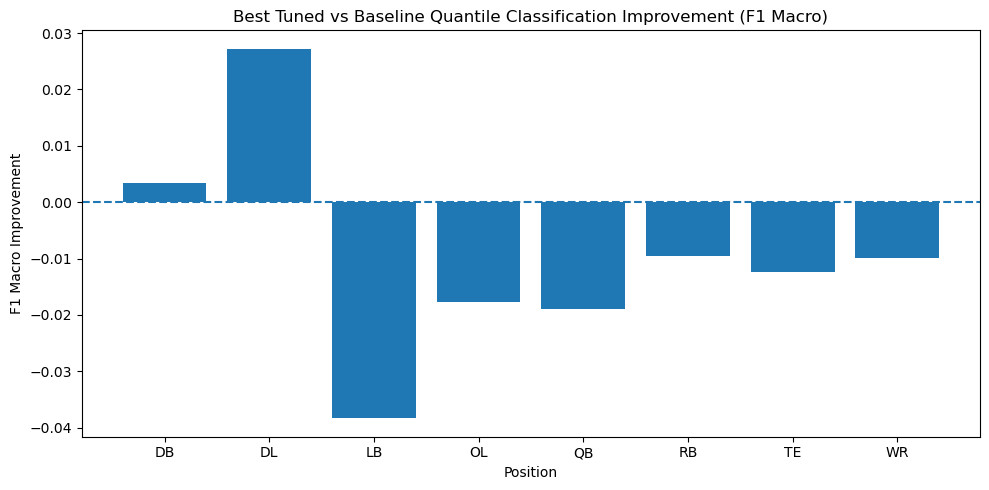

In [72]:
# quantile classification F1 improvement plot
plt.figure(figsize = (10, 5))
plt.bar(q_compare["position"], q_compare["improvement"])
plt.axhline(0, linestyle="--")
plt.title("Best Tuned vs Baseline Quantile Classification Improvement (F1 Macro)")
plt.xlabel("Position")
plt.ylabel("F1 Macro Improvement")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tuned_vs_baseline_quantile_improvement.png")
plt.show()

# Summary

In [73]:
# Comparison
print("Regression comparison:")
display(reg_compare.sort_values("improvement", ascending=False))

print("Binary classification comparison:")
display(bin_compare.sort_values("improvement", ascending=False))

print("Quantile classification comparison:")
display(q_compare.sort_values("improvement", ascending=False))

Regression comparison:


,position,baseline_model,baseline_rmse,tuned_model,tuned_rmse,improvement
0,DB,SVR,8.621390,SVR,8.558056,0.063334
7,WR,Ridge,12.871412,Ridge,12.864729,0.006683
5,RB,SVR,11.873728,SVR,11.923575,-0.049847
6,TE,SVR,7.034330,SVR,7.225329,-0.190999
2,LB,SVR,10.232549,SVR,10.704925,-0.472376
4,QB,RF,17.047866,RF,18.777544,-1.729678
1,DL,SVR,8.547665,SVR,10.545664,-1.997999
3,OL,SVR,9.601728,SVR,12.764396,-3.162668


Binary classification comparison:


,position,baseline_model,baseline_f1_macro,tuned_model,tuned_f1_macro,improvement
4,QB,GB,0.715100,ExtraTrees,0.753762,0.038662
0,DB,SVC,0.552299,SVC,0.588134,0.035835
3,OL,ExtraTrees,0.588779,GB,0.608571,0.019793
7,WR,Logistic,0.596221,ExtraTrees,0.606436,0.010215
5,RB,ExtraTrees,0.594502,GB,0.598515,0.004014
1,DL,NaiveBayes,0.620833,NaiveBayes,0.620833,0.000000
2,LB,GB,0.579288,GB,0.579288,0.000000
6,TE,SVC,0.645299,SVC,0.645299,0.000000


Quantile classification comparison:


,position,baseline_model,baseline_f1_macro,tuned_model,tuned_f1_macro,improvement
1,DL,CatBoost,0.388986,ExtraTrees,0.416198,0.027213
0,DB,CatBoost,0.396061,Logistic,0.399555,0.003494
5,RB,RF,0.397187,ExtraTrees,0.387604,-0.009583
7,WR,Logistic,0.469862,Logistic,0.459942,-0.009920
6,TE,Logistic,0.373840,Logistic,0.361516,-0.012324
3,OL,ExtraTrees,0.404421,ExtraTrees,0.386715,-0.017706
4,QB,ExtraTrees,0.413781,Logistic,0.394768,-0.019013
2,LB,XGBoost,0.344294,ExtraTrees,0.305966,-0.038328


In [74]:
# Final summary tables
print("=== FINAL TUNED REGRESSION SUMMARY ===")
display(best_tuned_reg[["position", "model", "rmse", "mae", "r2"]])

print("=== FINAL TUNED BINARY SUMMARY ===")
display(best_tuned_bin[["position", "model", "accuracy", "f1_macro", "recall_star"]])

print("=== FINAL TUNED QUANTILE SUMMARY ===")
display(best_tuned_q[["position", "model", "accuracy", "f1_macro", "recall_star"]])

=== FINAL TUNED REGRESSION SUMMARY ===


,position,model,rmse,mae,r2
0,DB,SVR,8.558056,7.033873,0.012467
1,DL,SVR,10.545664,8.629539,-0.678505
2,LB,SVR,10.704925,8.837104,-0.113117
3,OL,SVR,12.764396,10.991257,-0.904515
4,QB,RF,18.777544,15.016533,0.144564
5,RB,SVR,11.923575,9.691476,-0.049946
6,TE,SVR,7.225329,5.790290,-0.023387
7,WR,Ridge,12.864729,10.263158,0.077544


=== FINAL TUNED BINARY SUMMARY ===


,position,model,accuracy,f1_macro,recall_star
0,DB,SVC,0.614634,0.588134,0.711538
1,DL,NaiveBayes,0.780220,0.620833,0.521739
2,LB,GB,0.723077,0.579288,0.346154
3,OL,GB,0.766423,0.608571,0.450000
4,QB,ExtraTrees,0.800000,0.753762,0.611111
5,RB,GB,0.720339,0.598515,0.400000
6,TE,SVC,0.759036,0.645299,0.500000
7,WR,ExtraTrees,0.705882,0.606436,0.395833


=== FINAL TUNED QUANTILE SUMMARY ===


,position,model,accuracy,f1_macro,recall_star
0,DB,Logistic,0.404878,0.399555,0.615385
1,DL,ExtraTrees,0.439560,0.416198,0.739130
2,LB,ExtraTrees,0.307692,0.305966,0.571429
3,OL,ExtraTrees,0.401460,0.386715,0.571429
4,QB,Logistic,0.450000,0.394768,0.473684
5,RB,ExtraTrees,0.389831,0.387604,0.518519
6,TE,Logistic,0.373494,0.361516,0.666667
7,WR,Logistic,0.465241,0.459942,0.395833


In [75]:
# Average final performance by category
category_score_summary = pd.DataFrame({
    "category": ["Regression", "Binary", "Quantile"],
    "main_metric": ["r2", "f1_macro", "f1_macro"],
    "avg_final_score": [
        best_tuned_reg["r2"].mean(),
        best_tuned_bin["f1_macro"].mean(),
        best_tuned_q["f1_macro"].mean(),
    ],
    "std_final_score": [
        best_tuned_reg["r2"].std(),
        best_tuned_bin["f1_macro"].std(),
        best_tuned_q["f1_macro"].std(),
    ],
})

category_improvement_summary = pd.DataFrame({
    "category": ["Regression", "Binary", "Quantile"],
    "comparison_metric": ["rmse", "f1_macro", "f1_macro"],
    "avg_absolute_improvement": [
        reg_compare["improvement"].mean(),
        bin_compare["improvement"].mean(),
        q_compare["improvement"].mean(),
    ],
    "std_absolute_improvement": [
        reg_compare["improvement"].std(),
        bin_compare["improvement"].std(),
        q_compare["improvement"].std(),
    ],
})

print("=== CATEGORY SCORE SUMMARY ===")
display(category_score_summary)


print("=== CATEGORY IMPROVEMENT SUMMARY ===")
display(category_improvement_summary)

=== CATEGORY SCORE SUMMARY ===


,category,main_metric,avg_final_score,std_final_score
0,Regression,r2,-0.191862,0.383020
1,Binary,f1_macro,0.625105,0.055772
2,Quantile,f1_macro,0.389033,0.044036


=== CATEGORY IMPROVEMENT SUMMARY ===


,category,comparison_metric,avg_absolute_improvement,std_absolute_improvement
0,Regression,rmse,-0.941694,1.204641
1,Binary,f1_macro,0.013565,0.016120
2,Quantile,f1_macro,-0.009521,0.018950


In [76]:
# percent improvement over baseline
reg_compare_pct = reg_compare.copy()
reg_compare_pct["pct_improvement"] = (
    reg_compare_pct["improvement"] / reg_compare_pct["baseline_rmse"]
)

bin_compare_pct = bin_compare.copy()
bin_compare_pct["pct_improvement"] = (
    bin_compare_pct["improvement"] / bin_compare_pct["baseline_f1_macro"]
)

q_compare_pct = q_compare.copy()
q_compare_pct["pct_improvement"] = (
    q_compare_pct["improvement"] / q_compare_pct["baseline_f1_macro"]
)

category_pct_summary = pd.DataFrame({
    "category": ["Regression", "Binary", "Quantile"],
    "avg_pct_improvement": [
        reg_compare_pct["pct_improvement"].mean(),
        bin_compare_pct["pct_improvement"].mean(),
        q_compare_pct["pct_improvement"].mean(),
    ],
    "std_pct_improvement": [
        reg_compare_pct["pct_improvement"].std(),
        bin_compare_pct["pct_improvement"].std(),
        q_compare_pct["pct_improvement"].std(),
    ],
})

print("=== CATEGORY PERCENT IMPROVEMENT SUMMARY ===")
display(category_pct_summary)


=== CATEGORY PERCENT IMPROVEMENT SUMMARY ===


,category,avg_pct_improvement,std_pct_improvement
0,Regression,-0.091780,0.124773
1,Binary,0.022056,0.025940
2,Quantile,-0.025060,0.051386


In [77]:
# Position-level comparison
position_task_summary = pd.DataFrame({
    "position": best_tuned_reg["position"],
    "regression_r2": best_tuned_reg["r2"].values,
    "binary_f1_macro": best_tuned_bin.set_index("position").loc[best_tuned_reg["position"], "f1_macro"].values,
    "quantile_f1_macro": best_tuned_q.set_index("position").loc[best_tuned_reg["position"], "f1_macro"].values,
})

print("=== POSITION-LEVEL COMPARISON ===")
display(position_task_summary)

=== POSITION-LEVEL COMPARISON ===


,position,regression_r2,binary_f1_macro,quantile_f1_macro
0,DB,0.012467,0.588134,0.399555
1,DL,-0.678505,0.620833,0.416198
2,LB,-0.113117,0.579288,0.305966
3,OL,-0.904515,0.608571,0.386715
4,QB,0.144564,0.753762,0.394768
5,RB,-0.049946,0.598515,0.387604
6,TE,-0.023387,0.645299,0.361516
7,WR,0.077544,0.606436,0.459942


In [78]:
category_score_summary.to_csv(TABLES_DIR / "category_score_summary.csv", index = False)
category_improvement_summary.to_csv(TABLES_DIR / "category_improvement_summary.csv", index = False)
category_pct_summary.to_csv(TABLES_DIR / "category_percent_improvement_summary.csv", index = False)
position_task_summary.to_csv(TABLES_DIR / "position_task_summary.csv", index = False)

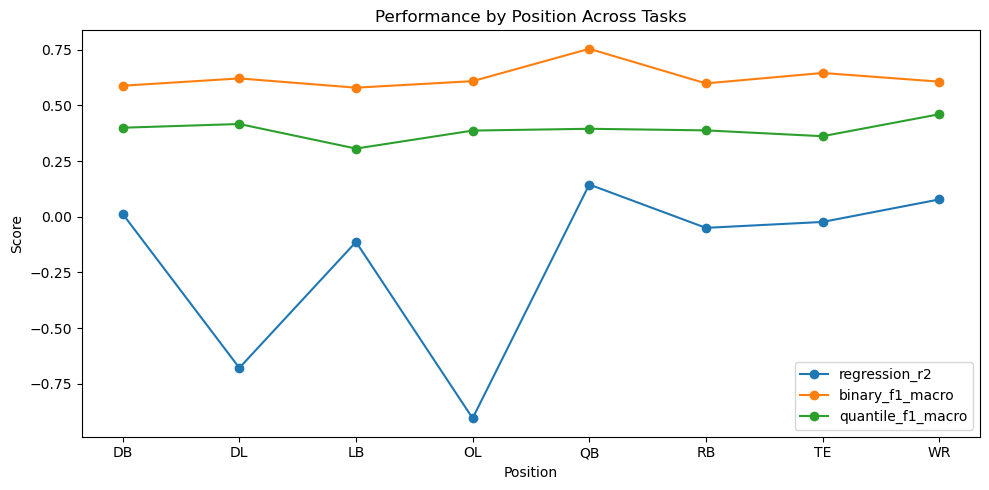

In [79]:
# Position-level performance plot
plot_df = position_task_summary.set_index("position")

plt.figure(figsize=(10, 5))
for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], marker="o", label=col)

plt.title("Performance by Position Across Tasks")
plt.xlabel("Position")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "position_performance_across_tasks.png", dpi=300)
plt.show()

accuracy for classification
